Iteration 0: Cost = 0.490050, w = 0.0100, b = 0.0000
Iteration 100: Cost = 0.065657, w = 0.6376, b = -0.0000
Iteration 200: Cost = 0.008797, w = 0.8674, b = -0.0000
Iteration 300: Cost = 0.001179, w = 0.9514, b = -0.0000
Iteration 400: Cost = 0.000158, w = 0.9822, b = -0.0000
Iteration 500: Cost = 0.000021, w = 0.9935, b = -0.0000
Iteration 600: Cost = 0.000003, w = 0.9976, b = -0.0000
Iteration 700: Cost = 0.000000, w = 0.9991, b = -0.0000
Iteration 800: Cost = 0.000000, w = 0.9997, b = -0.0000
Iteration 900: Cost = 0.000000, w = 0.9999, b = -0.0000

Final parameters:
w (weight) = 1.0000
b (bias) = -0.0000
Final cost = 0.000000


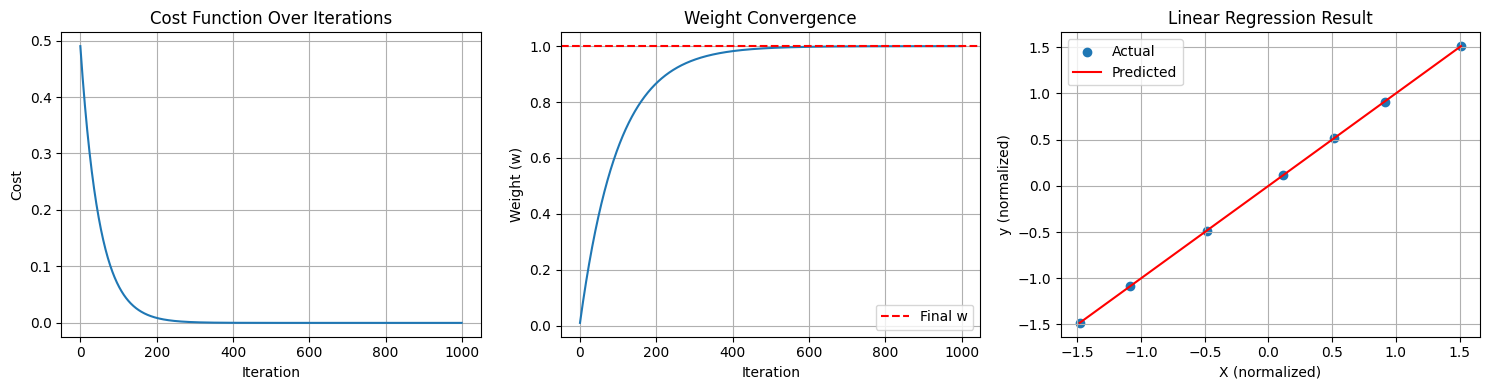


✓ How gradient descent works:
1. Start with random w=0.0, b=0.0
2. Compute cost: 0.490050
3. Compute gradients (direction to minimize)
4. Update w = w - learning_rate * dw
5. Update b = b - learning_rate * db
6. Repeat 1000 times
7. Final w=1.0000, b=-0.0000, cost=0.000000

✓ Key insight: We 'walk down' the cost function using gradients!
Iteration 0: Cost = 0.499001, w = 0.0010, b = 0.0000
Iteration 100: Cost = 0.408506, w = 0.0961, b = -0.0000
Iteration 200: Cost = 0.334423, w = 0.1822, b = -0.0000
Iteration 300: Cost = 0.273775, w = 0.2600, b = -0.0000
Iteration 400: Cost = 0.224126, w = 0.3305, b = -0.0000
Iteration 500: Cost = 0.183480, w = 0.3942, b = -0.0000
Iteration 600: Cost = 0.150206, w = 0.4519, b = -0.0000
Iteration 700: Cost = 0.122966, w = 0.5041, b = -0.0000
Iteration 800: Cost = 0.100666, w = 0.5513, b = -0.0000
Iteration 900: Cost = 0.082410, w = 0.5940, b = -0.0000
Iteration 0: Cost = 0.490050, w = 0.0100, b = 0.0000
Iteration 100: Cost = 0.065657, w = 0.6376, b = -

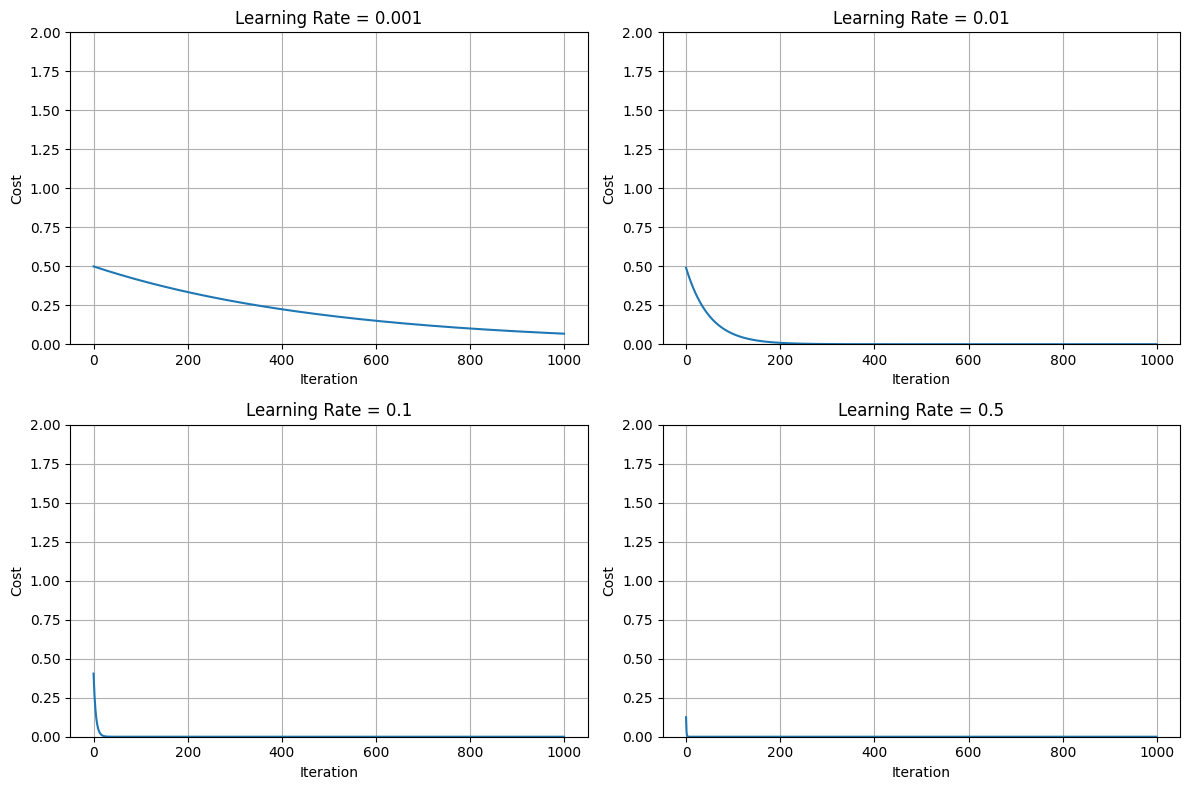


Comparison:
LR=0.001: Final cost=0.067600, w=0.6323
LR=0.01: Final cost=0.000000, w=1.0000
LR=0.1: Final cost=0.000000, w=1.0000
LR=0.5: Final cost=0.000000, w=1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============ SIMPLE LINEAR REGRESSION WITH GRADIENT DESCENT ============

# Small dataset: House size vs price
X = np.array([1000, 1200, 1500, 1800, 2000, 2200, 2500])
y = np.array([200000, 240000, 300000, 360000, 400000, 440000, 500000])

# Normalize X for better learning
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

def compute_cost(X, y, w, b):
    """
    Compute cost function: J = (1/2m) * sum((f(x) - y)^2)
    where f(x) = w*x + b
    """
    m = len(X)
    f_x = w * X + b
    cost = np.sum((f_x - y) ** 2) / (2 * m)
    return cost

def compute_gradients(X, y, w, b):
    """
    Compute gradients dJ/dw and dJ/db
    dJ/dw = (1/m) * sum((f(x) - y) * x)
    dJ/db = (1/m) * sum((f(x) - y))
    """
    m = len(X)
    f_x = w * X + b
    dw = np.sum((f_x - y) * X) / m
    db = np.sum(f_x - y) / m
    return dw, db

def gradient_descent(X, y, w_init, b_init, learning_rate, iterations):
    """
    Run gradient descent algorithm
    """
    w = w_init
    b = b_init
    cost_history = []
    w_history = []
    b_history = []
    
    for i in range(iterations):
        # Compute gradients
        dw, db = compute_gradients(X, y, w, b)
        
        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        # Store cost and parameters
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        w_history.append(w)
        b_history.append(b)
        
        # Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}, w = {w:.4f}, b = {b:.4f}")
    
    return w, b, cost_history, w_history, b_history

# ============ RUN GRADIENT DESCENT ============

# Initial values
w_init = 0.0
b_init = 0.0
learning_rate = 0.01
iterations = 1000

# Run optimization
w_final, b_final, cost_hist, w_hist, b_hist = gradient_descent(
    X, y, w_init, b_init, learning_rate, iterations
)

print(f"\nFinal parameters:")
print(f"w (weight) = {w_final:.4f}")
print(f"b (bias) = {b_final:.4f}")
print(f"Final cost = {cost_hist[-1]:.6f}")

# ============ VISUALIZE RESULTS ============

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Cost function over iterations
axes[0].plot(cost_hist)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost Function Over Iterations')
axes[0].grid()

# 2. Weight convergence
axes[1].plot(w_hist)
axes[1].axhline(y=w_final, color='r', linestyle='--', label='Final w')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Weight (w)')
axes[1].set_title('Weight Convergence')
axes[1].legend()
axes[1].grid()

# 3. Predictions vs Actual
f_x = w_final * X + b_final
axes[2].scatter(X, y, label='Actual')
axes[2].plot(X, f_x, color='red', label='Predicted')
axes[2].set_xlabel('X (normalized)')
axes[2].set_ylabel('y (normalized)')
axes[2].set_title('Linear Regression Result')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

# ============ UNDERSTAND THE PROCESS ============

print(f"\n✓ How gradient descent works:")
print(f"1. Start with random w={w_init}, b={b_init}")
print(f"2. Compute cost: {cost_hist[0]:.6f}")
print(f"3. Compute gradients (direction to minimize)")
print(f"4. Update w = w - learning_rate * dw")
print(f"5. Update b = b - learning_rate * db")
print(f"6. Repeat 1000 times")
print(f"7. Final w={w_final:.4f}, b={b_final:.4f}, cost={cost_hist[-1]:.6f}")
print(f"\n✓ Key insight: We 'walk down' the cost function using gradients!")

# ============ EXPERIMENT: DIFFERENT LEARNING RATES ============

learning_rates = [0.001, 0.01, 0.1, 0.5]
results = {}

plt.figure(figsize=(12, 8))

for idx, lr in enumerate(learning_rates, 1):
    w, b, cost_hist, _, _ = gradient_descent(
        X, y, 0.0, 0.0, lr, 1000
    )
    results[lr] = (w, b, cost_hist)
    
    plt.subplot(2, 2, idx)
    plt.plot(cost_hist)
    plt.title(f'Learning Rate = {lr}')
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.ylim([0, 2])
    plt.grid()

plt.tight_layout()
plt.show()

print("\nComparison:")
for lr, (w, b, cost_hist) in results.items():
    print(f"LR={lr}: Final cost={cost_hist[-1]:.6f}, w={w:.4f}")

